# Bài tập Thực hành 5: Mini-Project – Phân loại Âm thanh (Audio Classification) với 2D-CNN / ResNet bằng PyTorch Audio Pipeline

Trong bài tập thực hành nâng cao này, các bạn sẽ ứng dụng các biểu diễn không gian - thời gian 2D (Spectrogram) vào một quy trình Deep Learning phân loại âm thanh hoàn chỉnh (**Audio Torch Pipeline**) sử dụng PyTorch:

1. **Tải & Nạp Dữ liệu Âm thanh**: Sử dụng bộ dữ liệu `Speech Commands Dataset` từ internet, xây dựng lớp PyTorch `Dataset` và `DataLoader` để đọc và chuẩn hóa dạng sóng Waveform.
2. **Chuyển đổi Biểu diễn On-the-Fly**: Thiết lập các phép biến đổi trực tiếp trên PyTorch/Torchaudio:
   - Dạng sóng thô **Raw 1D Waveform**.
   - Phổ tần số tuyến tính **Linear Spectrogram (STFT)** quy đổi sang dB.
   - Phổ tần số thang đo cảm nhận **Log-Mel Spectrogram (80 Mel bands)** quy đổi sang dB.
3. **Xây dựng Mạng Neural PyTorch**: Thiết kế mạng CNN 1D cho Waveform và mạng CNN 2D cho Spectrogram.
4. **Huấn luyện & Đánh giá Mô hình**: Lập trình vòng lặp huấn luyện (Training Loop) với tối ưu hóa Adam và CrossEntropyLoss.
5. **Thực nghiệm So sánh**: So sánh hiệu năng phân loại giữa **Raw 1D-CNN** vs **Linear Spectrogram 2D-CNN** vs **Log-Mel Spectrogram 2D-CNN**.
6. **Trực quan hóa & Thảo luận**: Vẽ biểu đồ học tập (Learning Curves), ma trận nhầm lẫn (Confusion Matrix) và phân tích vai trò của thang đo Mel/Logarit.

## 1. Import các thư viện cần thiết
Chạy cell dưới đây để nạp các thư viện PyTorch (`torch`, `torch.nn`, `torchaudio`), nạp file (`urllib`, `zipfile`, `glob`), xử lý âm thanh (`librosa`), xử lý mảng số (`numpy`), đánh giá (`sklearn.metrics`) và trực quan hóa (`matplotlib`, `seaborn`).

In [8]:
# Chạy lệnh này trong terminal nếu chưa cài đặt thư viện:
# pip install torch torchaudio librosa numpy matplotlib scikit-learn seaborn scipy

import os
import glob
import zipfile
import urllib.request
import time
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchaudio
import torchaudio.transforms as T
from sklearn.metrics import classification_report, confusion_matrix

# Thiết lập thiết bị tính toán (CPU hoặc GPU/CUDA)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"Torchaudio version: {torchaudio.__version__}")
print(f"Dang su dung thiet bi: {device}")


PyTorch version: 2.11.0+cu128
Torchaudio version: 2.11.0+cu128
Dang su dung thiet bi: cuda


## 2. Tải Dữ liệu Âm thanh & Lập trình Lớp PyTorch `AudioDataset`
Chúng ta tải bộ dữ liệu **Mini Speech Commands Dataset** và chọn 4 lớp lệnh giọng nói cơ bản: `['yes', 'no', 'up', 'down']`.
Lớp `AudioDataset` kế thừa từ `torch.utils.data.Dataset` sẽ:
1. Đọc file âm thanh `.wav` bằng `torchaudio.load()` hoặc `librosa.load()`.
2. Chuẩn hóa độ dài tín hiệu dạng sóng về cố định $1\text{ giây}$ ($16000\text{ samples}$ ở tần số lấy mẫu $16000\text{ Hz}$) bằng cách đệm số 0 (padding) hoặc cắt ngắn (cropping).
3. Trả về tensor dạng sóng $1D$ kích thước `(1, 16000)` cùng nhãn nhị phân/đa lớp `y`.

In [9]:
# TODO 1: Viết lớp SpeechCommandsDataset kế thừa torch.utils.data.Dataset
# Yêu cầu:
# 1. Tải 'https://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip' nếu chưa có.
# 2. Giải nén vào thư mục 'dataset_speech_commands'.
# 3. Lọc danh sách file thuộc 4 lớp: ['yes', 'no', 'up', 'down']. Lấy khoảng 250 mẫu cho mỗi lớp.
# 4. Hàm __getitem__(self, idx): đọc file âm thanh, đảm bảo độ dài đúng 16000 mẫu.
#    Nếu len < 16000 -> pad 0 phía sau.
#    Nếu len > 16000 -> cắt lấy 16000 mẫu đầu.
# 5. Trả về waveform dạng torch.Tensor kích thước (1, 16000) và label dạng int.

url = 'https://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip'
zip_path = 'mini_speech_commands.zip'
extract_dir = 'dataset_speech_commands'

if not os.path.exists(zip_path) and not os.path.exists(extract_dir):
    print("Dang tai bo du lieu Speech Commands tu internet...")
    urllib.request.urlretrieve(url, zip_path)

if not os.path.exists(extract_dir):
    print("Dang giai nen bo du lieu...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

CLASSES = ['yes', 'no', 'up', 'down']
label_to_idx = {cls: idx for idx, cls in enumerate(CLASSES)}


class SpeechCommandsDataset(Dataset):
    def __init__(self, root_dir, classes, max_samples_per_class=250, target_sr=16000):
        self.file_list = []
        self.labels = []
        self.target_sr = target_sr
        self.target_length = target_sr

        for class_name in classes:
            class_files = sorted(
                glob.glob(os.path.join(root_dir, '**', class_name, '*.wav'), recursive=True)
            )[:max_samples_per_class]
            self.file_list.extend(class_files)
            self.labels.extend([label_to_idx[class_name]] * len(class_files))

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        waveform, sample_rate = torchaudio.load(self.file_list[idx])

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sample_rate != self.target_sr:
            waveform = torchaudio.functional.resample(
                waveform, sample_rate, self.target_sr
            )

        if waveform.shape[1] < self.target_length:
            waveform = nn.functional.pad(
                waveform, (0, self.target_length - waveform.shape[1])
            )
        else:
            waveform = waveform[:, :self.target_length]

        return waveform.float(), self.labels[idx]


full_dataset = SpeechCommandsDataset(extract_dir, CLASSES, max_samples_per_class=250)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Tong so mau du lieu: {len(full_dataset)} (Train: {len(train_dataset)}, Val: {len(val_dataset)})")

Tong so mau du lieu: 1000 (Train: 800, Val: 200)


## 3. Xây dựng các Phép Biến đổi Âm thanh (Audio Transforms) On-the-Fly
Chúng ta thiết lập 3 đường ống chuyển đổi dữ liệu (Transforms) bằng `torchaudio.transforms`:
1. **Raw 1D Waveform**: Giữ nguyên tín hiệu dạng sóng $1D$ `(1, 16000)`.
2. **Linear Spectrogram (STFT)**: Sử dụng `torchaudio.transforms.Spectrogram(n_fft=512, hop_length=160)` kết hợp với `torchaudio.transforms.AmplitudeToDB()` để chuyển sang dB. Kích thước đầu ra: `(1, 257, 101)`.
3. **Log-Mel Spectrogram**: Sử dụng `torchaudio.transforms.MelSpectrogram(sample_rate=16000, n_fft=512, hop_length=160, n_mels=80)` kết hợp `AmplitudeToDB()`. Kích thước đầu ra: `(1, 80, 101)`.

In [10]:
# TODO 2: Khai báo 3 đối tượng Transform sử dụng torchaudio.transforms
# Yêu cầu:
# 1. transform_raw: nn.Identity() (giữ nguyên waveform 1D)
# 2. transform_linear: nn.Sequential(T.Spectrogram(n_fft=512, hop_length=160), T.AmplitudeToDB())
# 3. transform_logmel: nn.Sequential(T.MelSpectrogram(sample_rate=16000, n_fft=512, hop_length=160, n_mels=80), T.AmplitudeToDB())

transform_raw = nn.Identity()
transform_linear = nn.Sequential(
    torchaudio.transforms.Spectrogram(n_fft=512, hop_length=160),
    torchaudio.transforms.AmplitudeToDB()
)
transform_logmel = nn.Sequential(
    torchaudio.transforms.MelSpectrogram(sample_rate=16000, n_fft=512, hop_length=160, n_mels=80),
    torchaudio.transforms.AmplitudeToDB()
)

# Kiểm tra kích thước output của từng transform đối với 1 sample ngẫu nhiên
if len(full_dataset) > 0:
    sample_wave, _ = full_dataset[0]
    if transform_raw is not None:
        print(f"Raw Waveform shape: {transform_raw(sample_wave).shape}")
    if transform_linear is not None:
        print(f"Linear Spectrogram shape: {transform_linear(sample_wave).shape}")
    if transform_logmel is not None:
        print(f"Log-Mel Spectrogram shape: {transform_logmel(sample_wave).shape}")


Raw Waveform shape: torch.Size([1, 16000])
Linear Spectrogram shape: torch.Size([1, 257, 101])
Log-Mel Spectrogram shape: torch.Size([1, 80, 101])


## 4. Thiết kế các Kiến trúc Mạng Neural PyTorch
Chúng ta thiết kế 2 kiến trúc mạng Neural:

### 1. Mạng `Raw1DCNN` (Xử lý dạng sóng 1D):
Xử lý trực tiếp tín hiệu `(batch, 1, 16000)` thông qua các lớp `Conv1d` -> `BatchNorm1d` -> `ReLU` -> `MaxPool1d`.

### 2. Mạng `Audio2DCNN` (Xử lý biểu diễn 2D Spectrogram):
Xử lý ảnh phổ 2D `(batch, 1, F, T)` thông qua các lớp `Conv2d` -> `BatchNorm2d` -> `ReLU` -> `MaxPool2d` -> `AdaptiveAvgPool2d((1, 1))` -> `Linear`.

In [11]:
# TODO 3: Định nghĩa hai lớp mô hình Raw1DCNN và Audio2DCNN
# Yêu cầu:
# 1. Lớp Raw1DCNN(num_classes=4):
#    - Conv1d(1, 16, kernel_size=80, stride=16) -> BN1d -> ReLU -> MaxPool1d(4)
#    - Conv1d(16, 32, kernel_size=3, padding=1) -> BN1d -> ReLU -> MaxPool1d(4)
#    - Conv1d(32, 64, kernel_size=3, padding=1) -> BN1d -> ReLU -> AdaptiveAvgPool1d(1)
#    - Flatten -> Linear(64, num_classes)
#
# 2. Lớp Audio2DCNN(num_classes=4):
#    - Conv2d(1, 16, kernel_size=3, padding=1) -> BN2d -> ReLU -> MaxPool2d(2, 2)
#    - Conv2d(16, 32, kernel_size=3, padding=1) -> BN2d -> ReLU -> MaxPool2d(2, 2)
#    - Conv2d(32, 64, kernel_size=3, padding=1) -> BN2d -> ReLU -> AdaptiveAvgPool2d((1, 1))
#    - Flatten -> Linear(64, num_classes)

class Raw1DCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(Raw1DCNN, self).__init__()
        # Điền code khởi tạo kiến trúc Raw1DCNN ở đây:
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=80, stride=16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # Điền code luồng dữ liệu forward ở đây:
        x = self.features(x)
        x = x.flatten(start_dim=1)
        return self.classifier(x)

class Audio2DCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(Audio2DCNN, self).__init__()
        # Điền code khởi tạo kiến trúc Audio2DCNN ở đây:
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # Điền code luồng dữ liệu forward ở đây:
        x = self.features(x)
        x = x.flatten(start_dim=1)
        return self.classifier(x)

print("Da dinh nghia xong hai kien truc mang Raw1DCNN va Audio2DCNN.")


Da dinh nghia xong hai kien truc mang Raw1DCNN va Audio2DCNN.


## 5. Viết Hàm Huấn luyện & Đánh giá Model PyTorch
Chúng ta lập trình hàm `train_model(model, train_loader, val_loader, transform, epochs=5, lr=0.001)` để huấn luyện mạng qua từng epoch, tính toán Loss và Validation Accuracy.

In [12]:
# TODO 4: Viết hàm train_model thực thi quá trình huấn luyện và kiểm thử PyTorch
# Yêu cầu:
# 1. Đưa mô hình và transform lên device (CPU/GPU), khởi tạo nn.CrossEntropyLoss() và optim.Adam(model.parameters(), lr=lr).
# 2. Vòng lặp qua từng epoch:
#    - Với mỗi batch (waveforms, labels) trong train_loader:
#      + Đưa waveforms và labels lên device: waveforms = waveforms.to(device), targets = labels.to(device).
#      + Biến đổi inputs = transform(waveforms).
#      + Tính outputs = model(inputs), loss = criterion(outputs, targets).
#      + Cập nhật trọng số bằng optimizer.zero_grad(), loss.backward(), optimizer.step().
#    - Đánh giá trên val_loader (dùng torch.no_grad()): tính val_loss và val_accuracy.
# 3. Trả về lịch sử train_losses, val_accuracies, mảng y_true và y_pred trên tập Validation.

def train_model(model, train_loader, val_loader, transform, epochs=5, lr=0.001):
    # Điền code huấn luyện mô hình PyTorch ở đây:
    model = model.to(device)
    transform = transform.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_accuracies = []

    best_targets = []
    best_preds = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total_train = 0

        for waveforms, labels in train_loader:
            waveforms = waveforms.to(device)
            targets = labels.to(device)

            inputs = transform(waveforms)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * targets.size(0)
            total_train += targets.size(0)

        train_loss = running_loss / total_train
        train_losses.append(train_loss)

        model.eval()
        correct = 0
        total_val = 0
        all_preds = []
        all_targets = []
        val_running_loss = 0.0

        with torch.no_grad():
            for waveforms, labels in val_loader:
                waveforms = waveforms.to(device)
                targets = labels.to(device)

                inputs = transform(waveforms)
                outputs = model(inputs)

                loss = criterion(outputs, targets)
                predictions = outputs.argmax(dim=1)

                val_running_loss += loss.item() * targets.size(0)
                correct += (predictions == targets).sum().item()
                total_val += targets.size(0)

                all_preds.extend(predictions.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())

        val_accuracy = correct / total_val
        val_loss = val_running_loss / total_val

        val_accuracies.append(val_accuracy)
        best_targets = all_targets
        best_preds = all_preds

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f}"
        )
    
    return train_losses, val_accuracies, all_targets, all_preds

print("Da dinh nghia ham train_model.")


Da dinh nghia ham train_model.


## 6. Thực nghiệm So sánh 3 Loại Biểu diễn Âm thanh
Tiến hành huấn luyện 3 mô hình đại diện cho 3 dạng biểu diễn khác nhau (với cùng `epochs=5`):
1. **Thực nghiệm 1**: `Raw1DCNN` với `transform_raw` (Raw Waveform 1D).
2. **Thực nghiệm 2**: `Audio2DCNN` với `transform_linear` (Linear Spectrogram STFT dB).
3. **Thực nghiệm 3**: `Audio2DCNN` với `transform_logmel` (Log-Mel Spectrogram dB).

In [13]:
# TODO 5: Chạy huấn luyện 3 thực nghiệm và in bảng tổng hợp kết quả độ chính xác (Accuracy)
# Yêu cầu:
# 1. Khởi tạo model_raw = Raw1DCNN(num_classes=4), chạy train_model với transform_raw.
# 2. Khởi tạo model_linear = Audio2DCNN(num_classes=4), chạy train_model với transform_linear.
# 3. Khởi tạo model_logmel = Audio2DCNN(num_classes=4), chạy train_model với transform_logmel.
# 4. In bảng so sánh độ chính xác Validation Accuracy cuối cùng của 3 thực nghiệm.

print("=== THUC NGHIEM 1: RAW 1D-CNN ===")
# Điền code chạy thực nghiệm 1 ở đây:
model_raw = Raw1DCNN(num_classes=len(CLASSES))

raw_train_losses, raw_val_accuracies, raw_targets, raw_preds = train_model(
    model_raw,
    train_loader,
    val_loader,
    transform_raw,
    epochs=5,
)
print("\n=== THUC NGHIEM 2: LINEAR SPECTROGRAM 2D-CNN ===")
# Điền code chạy thực nghiệm 2 ở đây:
model_linear = Audio2DCNN(num_classes=len(CLASSES))

linear_train_losses, linear_val_accuracies, linear_targets, linear_preds = train_model(
    model_linear,
    train_loader,
    val_loader,
    transform_linear,
    epochs=5,
)

print("\n=== THUC NGHIEM 3: LOG-MEL SPECTROGRAM 2D-CNN ===")
model_logmel = Audio2DCNN(num_classes=len(CLASSES))

logmel_train_losses, logmel_val_accuracies, logmel_targets, logmel_preds = train_model(
    model_logmel,
    train_loader,
    val_loader,
    transform_logmel,
    epochs=5,
)


print("\n=== BANG SO SANH KET QUA ===")
print(f"Raw 1D-CNN:              {raw_val_accuracies[-1] * 100:.2f}%")
print(f"Linear Spectrogram CNN:  {linear_val_accuracies[-1] * 100:.2f}%")
print(f"Log-Mel Spectrogram CNN: {logmel_val_accuracies[-1] * 100:.2f}%")
# Điền code chạy thực nghiệm 3 ở đây:


=== THUC NGHIEM 1: RAW 1D-CNN ===
Epoch [1/5] | Train Loss: 1.3381 | Val Loss: 1.3881 | Val Accuracy: 0.3250
Epoch [2/5] | Train Loss: 1.2291 | Val Loss: 1.2874 | Val Accuracy: 0.4000
Epoch [3/5] | Train Loss: 1.1111 | Val Loss: 1.1450 | Val Accuracy: 0.5550
Epoch [4/5] | Train Loss: 1.0232 | Val Loss: 1.0597 | Val Accuracy: 0.5600
Epoch [5/5] | Train Loss: 0.9516 | Val Loss: 1.0153 | Val Accuracy: 0.5950

=== THUC NGHIEM 2: LINEAR SPECTROGRAM 2D-CNN ===
Epoch [1/5] | Train Loss: 1.3533 | Val Loss: 1.3435 | Val Accuracy: 0.3600
Epoch [2/5] | Train Loss: 1.3214 | Val Loss: 1.3594 | Val Accuracy: 0.2550
Epoch [3/5] | Train Loss: 1.2970 | Val Loss: 1.3007 | Val Accuracy: 0.3550
Epoch [4/5] | Train Loss: 1.2775 | Val Loss: 1.3317 | Val Accuracy: 0.3800
Epoch [5/5] | Train Loss: 1.2485 | Val Loss: 1.2747 | Val Accuracy: 0.4050

=== THUC NGHIEM 3: LOG-MEL SPECTROGRAM 2D-CNN ===
Epoch [1/5] | Train Loss: 1.3310 | Val Loss: 1.3869 | Val Accuracy: 0.2650
Epoch [2/5] | Train Loss: 1.2465 | Val L

## 7. Trực quan hóa & So sánh Kết quả Chi tiết
Vẽ đồ thị tổng hợp bao gồm:
1. Đường cong **Validation Accuracy** theo epoch của 3 loại biểu diễn.
2. **Ma trận Nhầm lẫn (Confusion Matrix)** của mô hình tốt nhất (**Log-Mel 2D-CNN**) bằng `sns.heatmap`.
3. Trực quan hóa so sánh dạng sóng **1D Waveform**, **Linear Spectrogram** và **Log-Mel Spectrogram** của 1 mẫu âm thanh.

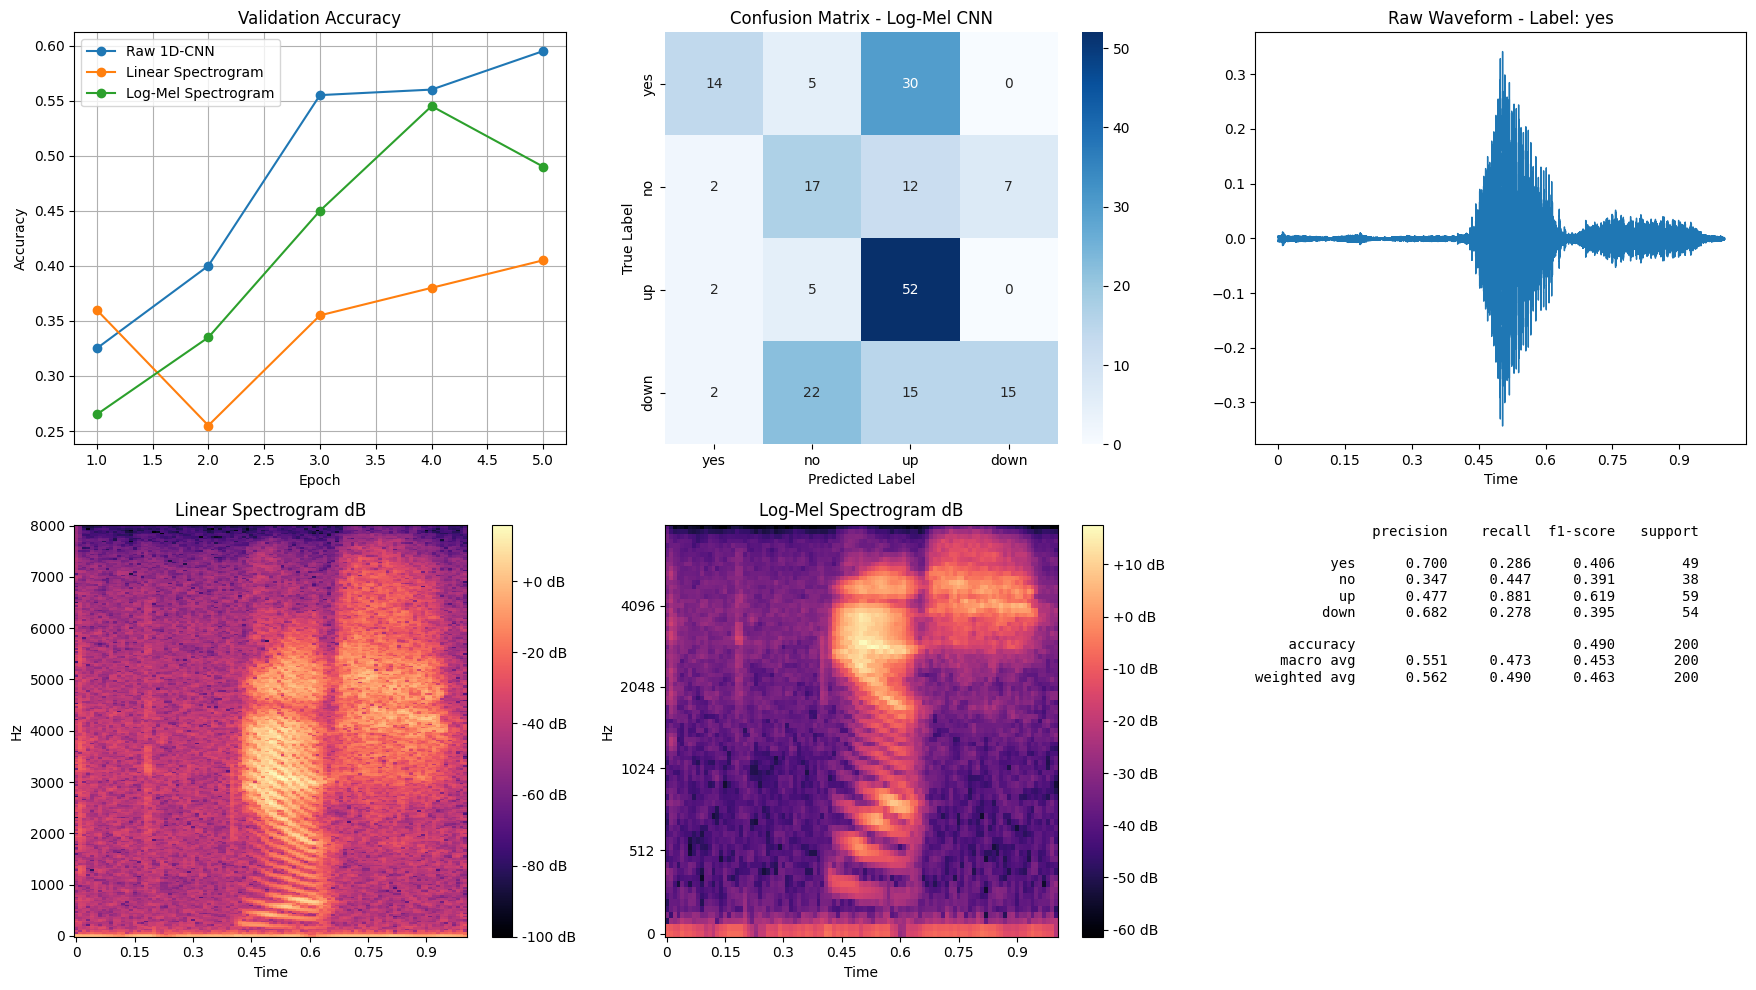

In [14]:
# TODO 6: Vẽ đồ thị so sánh Learning Curves, Confusion Matrix và hình ảnh các dạng biểu diễn
# Yêu cầu:
# 1. Subplot 1: Biểu đồ đường Validation Accuracy qua 5 epochs cho Raw 1D, Linear Spec và Log-Mel Spec.
# 2. Subplot 2: Heatmap Confusion Matrix 4x4 của mô hình Log-Mel 2D-CNN trên tập Validation.
# 3. Subplot 3 & 4: Trực quan hóa Linear Spectrogram và Log-Mel Spectrogram của 1 mẫu âm thanh bằng imshow/specshow.

# Điền code trực quan hóa đồ thị ở đây:

sample_wave, sample_label = full_dataset[0]
sample_wave_np = sample_wave.squeeze().numpy()

linear_spec = transform_linear(sample_wave.unsqueeze(0).to(device))
logmel_spec = transform_logmel(sample_wave.unsqueeze(0).to(device))

linear_spec_np = linear_spec.squeeze().detach().cpu().numpy()
logmel_spec_np = logmel_spec.squeeze().detach().cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Learning curves
axes[0, 0].plot(
    range(1, len(raw_val_accuracies) + 1),
    raw_val_accuracies,
    marker="o",
    label="Raw 1D-CNN",
)

axes[0, 0].plot(
    range(1, len(linear_val_accuracies) + 1),
    linear_val_accuracies,
    marker="o",
    label="Linear Spectrogram",
)

axes[0, 0].plot(
    range(1, len(logmel_val_accuracies) + 1),
    logmel_val_accuracies,
    marker="o",
    label="Log-Mel Spectrogram",
)

axes[0, 0].set_title("Validation Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].grid(True)
axes[0, 0].legend()

# 2. Confusion matrix
cm = confusion_matrix(
    logmel_targets,
    logmel_preds,
    labels=list(range(len(CLASSES))),
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=axes[0, 1],
)

axes[0, 1].set_title("Confusion Matrix - Log-Mel CNN")
axes[0, 1].set_xlabel("Predicted Label")
axes[0, 1].set_ylabel("True Label")

# 3. Waveform
librosa.display.waveshow(
    sample_wave_np,
    sr=16000,
    ax=axes[0, 2],
)

axes[0, 2].set_title(f"Raw Waveform - Label: {CLASSES[sample_label]}")
axes[0, 2].set_xlabel("Time")

# 4. Linear spectrogram
img1 = librosa.display.specshow(
    linear_spec_np,
    sr=16000,
    hop_length=160,
    x_axis="time",
    y_axis="linear",
    ax=axes[1, 0],
    cmap="magma",
)

axes[1, 0].set_title("Linear Spectrogram dB")
fig.colorbar(img1, ax=axes[1, 0], format="%+2.0f dB")

# 5. Log-Mel spectrogram
img2 = librosa.display.specshow(
    logmel_spec_np,
    sr=16000,
    hop_length=160,
    x_axis="time",
    y_axis="mel",
    ax=axes[1, 1],
    cmap="magma",
)

axes[1, 1].set_title("Log-Mel Spectrogram dB")
fig.colorbar(img2, ax=axes[1, 1], format="%+2.0f dB")

# 6. Classification report
axes[1, 2].axis("off")

report = classification_report(
    logmel_targets,
    logmel_preds,
    target_names=CLASSES,
    digits=3,
)

axes[1, 2].text(
    0.0,
    1.0,
    report,
    va="top",
    family="monospace",
    fontsize=10,
)

plt.tight_layout()
plt.show()


# plt.tight_layout()
# plt.show()


## 8. Câu hỏi thảo luận & Mở rộng

**Câu hỏi 1:** Tại sao biểu diễn **Log-Mel Spectrogram** lại vượt trội hơn so với **Linear Spectrogram (STFT)** và **Raw 1D Waveform** khi ứng dụng vào các mô hình Deep Learning phân loại âm thanh (2D-CNN/ResNet)? Hãy phân tích dưới góc độ sinh lý thính giác người và tính chất bất biến phổ (spectral shift invariance).

*Trả lời của sinh viên:*

Log-Mel Spectrogram thường cho kết quả tốt hơn vì nó biểu diễn tín hiệu gần với cách tai người cảm nhận âm thanh. Tai người không cảm nhận các tần số theo thang tuyến tính. Khả năng phân biệt tần số tốt hơn ở vùng tần số thấp và kém hơn ở vùng tần số cao. Thang Mel mô phỏng đặc điểm này bằng cách sử dụng các dải lọc hẹp ở tần số thấp và rộng hơn ở tần số cao.

Ngoài ra, việc chuyển năng lượng sang thang log giúp biểu diễn gần với cảm nhận độ lớn âm thanh của con người. Hai âm thanh có biên độ năng lượng rất khác nhau vẫn có thể được so sánh dễ dàng hơn sau khi chuyển sang dB.

So với Raw 1D Waveform, Log-Mel Spectrogram đã biến tín hiệu thành biểu diễn hai chiều gồm thời gian và tần số. CNN có thể học trực tiếp các mẫu cục bộ như formant, harmonic, onset và các vùng năng lượng đặc trưng của từng lớp âm thanh. Với waveform thô, mạng phải tự học cả phép biến đổi từ miền thời gian sang miền tần số nên thường cần nhiều dữ liệu và thời gian huấn luyện hơn.

So với Linear Spectrogram, Log-Mel Spectrogram giảm bớt số chiều và loại bỏ một phần chi tiết tần số không cần thiết đối với bài toán phân loại. Các đặc trưng quan trọng của tiếng nói thường nằm trong các vùng phổ tương đối ổn định. Vì vậy, những thay đổi nhỏ về tần số có thể vẫn giữ cấu trúc tương tự trên các dải Mel lân cận. Điều này tạo ra tính bất biến phổ tương đối, giúp mô hình ít nhạy với thay đổi nhỏ về cao độ, người nói hoặc thiết bị ghi âm.

Tuy nhiên, đây không phải là tính bất biến hoàn toàn. Nếu thay đổi tần số quá lớn thì mẫu phổ vẫn có thể chuyển sang các dải Mel khác và làm thay đổi dự đoán. Log-Mel chỉ giúp mô hình bền vững hơn trước các biến đổi nhỏ và phù hợp hơn với đặc điểm của âm thanh tiếng nói.


**Câu hỏi 2:** Phép biến đổi Logarithm biên độ (`AmplitudeToDB`) đóng vai trò thế nào đối với dải động (Dynamic Range) của tín hiệu âm thanh? Nếu bỏ qua bước chuyển đổi sang dB mà đưa trực tiếp năng lượng tuyến tính $X_{mel}$ vào mạng CNN 2D thì hiện tượng gì sẽ xảy ra với quá trình lan truyền ngược (Backpropagation)?

*Trả lời của sinh viên:*

Phép biến đổi `AmplitudeToDB` chuyển năng lượng hoặc biên độ tuyến tính sang thang logarithm, thường có dạng:

$$
X_{dB} = 10\log_{10}(X_{mel} + \epsilon)
$$

Trong đó $\epsilon$ là một số nhỏ nhằm tránh tính logarithm của số 0.

Tín hiệu âm thanh thường có dải động rất lớn: năng lượng của các vùng mạnh có thể lớn hơn rất nhiều lần so với năng lượng của các vùng yếu. Nếu giữ nguyên thang tuyến tính, các vùng năng lượng lớn sẽ chi phối gần như toàn bộ giá trị đầu vào, còn các chi tiết yếu dễ bị mất thông tin. Chuyển sang dB giúp nén dải động, làm cho các mức năng lượng khác nhau được phân bố cân bằng hơn và giúp mạng CNN quan sát được cả thành phần mạnh lẫn yếu.

Nếu bỏ qua bước chuyển đổi sang dB, đầu vào $X_{mel}$ có thể bị lệch về một số vùng giá trị rất lớn. Các lớp CNN đầu tiên dễ tạo ra activation lớn, làm gradient không ổn định và quá trình tối ưu khó khăn hơn. Trong một số trường hợp có thể xuất hiện gradient quá lớn, học dao động hoặc hội tụ chậm. Ngược lại, các vùng năng lượng nhỏ có thể tạo gradient rất yếu và gần như không đóng góp vào việc cập nhật trọng số.

Sau khi chuyển sang dB, giá trị đầu vào thường có phân bố phù hợp hơn với chuẩn hóa và các hàm kích hoạt của mạng. Điều này giúp quá trình lan truyền ngược ổn định hơn, làm nổi bật các thay đổi tương đối trong phổ thay vì chỉ tập trung vào biên độ tuyệt đối. Vì vậy, `AmplitudeToDB` không chỉ có ý nghĩa về mặt biểu diễn mà còn giúp cải thiện điều kiện tối ưu hóa của mô hình.